In [ ]:
import pandas as pd
import seaborn as sns
from google.colab import drive
import plotly.express as px


## Data breaches

In this notebook, we are going to discuss the information on the largest data breaches observed between 2004 and 2021.

The data is published under the CC0 license on [this kaggle page](https://www.kaggle.com/hishaamarmghan/list-of-top-data-breaches-2004-2021).

### Dataset contents

The dataset includes information on:

* **Year** - the year of the breach
* **Organization type** - industry sector of the organization affected by the breach
* **Method** - the event that resulted in the breach.
* **Records** - number of items in the breach
* **Count of Breaches** - number of breaches that occurred.

The necessary data is provided with the document: the code below imports the file.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_breaches = pd.read_csv('/content/drive/My Drive/Vis/Data Breaches/data_breaches.csv')
data_breaches

,Year,Organization type,Method,Total No Records (M),Count of Breaches
0,2016,healthcare,hacked,2.200000,1
1,2020,media,hacked,14.870304,1
2,2020,healthcare,poor security,0.566600,2
3,2013,tech,hacked,3350.159298,14
4,2019,tech,poor security,592.500000,4
...,...,...,...,...,...
163,2010,academic / educational,accidentally exposed,0.043000,1
164,2019,media,hacked,173.000000,1
165,2019,financial,hacked,0.098000,1
166,2020,financial,accidentally exposed,200.000000,1


## Notebook preparation

We want to start by making sure that the data has been correctly identified and make necessary conversions.

Based on data overview, we expect the first column to contain integers; the second and third: text-based data that correspond to two types of categories; next, we have the numeric counts of records; and finally, one more integer that stands for the number of breaches.

#### Checking data types

In [ ]:
data_breaches.dtypes

,0
Year,int64
Organization type,object
Method,object
Total No Records (M),float64
Count of Breaches,int64


We need to verify if the data has records where any of the columns is missing information.

In [ ]:
"complete records: " + str(len(data_breaches.dropna(how="any"))) + "; total records: " + str(len(data_breaches))

'complete records: 168; total records: 168'

### Converting organization types to categories

Let's look at the information on the types of affected organizations in the **Organization type** column.

In [ ]:
data_breaches["Organization type"].value_counts()

,count
Organization type,
tech,30
financial,30
government,24
healthcare,23
telecom,17
retail,15
media,10
other,10
academic / educational,9


In this case we can only identify the data type as a categorical one.

In [ ]:
data_breaches["Organization type"] = data_breaches["Organization type"].astype("category")

### Converting methods to categories

Let's look at the information on the types of affected organizations in the **Method** column.

In [ ]:
data_breaches["Method"].value_counts()

,count
Method,
hacked,76
poor security,28
lost / stolen media,24
inside job,16
accidentally exposed,14
unknown,4
misconfiguration,4
rogue contractor,1
social engineering,1


Also in this case we only make sure that the type of data is a Category.

In [ ]:
data_breaches["Method"] = data_breaches["Method"].astype("category")
data_breaches.dtypes

,0
Year,int64
Organization type,category
Method,category
Total No Records (M),float64
Count of Breaches,int64


In [ ]:
sns.set_theme()
sns.set_style("white")
sns.set_context("talk")

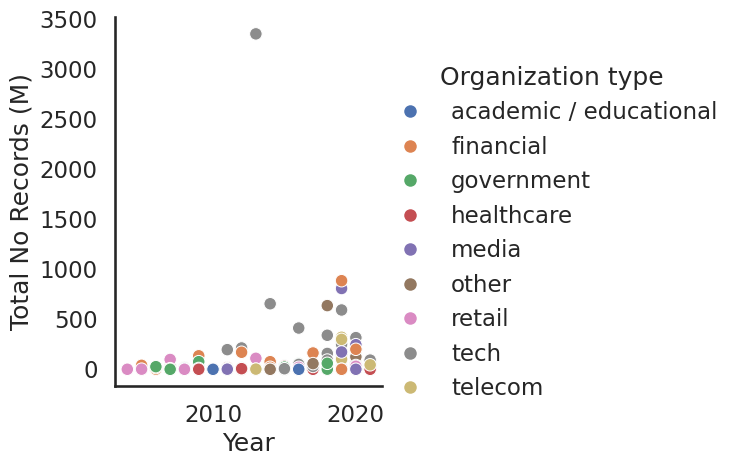

In [ ]:
sns.relplot(data=data_breaches,
	x=data_breaches["Year"],
	y=data_breaches["Total No Records (M)"],
	hue=data_breaches["Organization type"]
	);

create a blank space between the axis and the chart according to the specified value of the offset parameter
remove the indicated axis when its value is True (despine method documentation)

We define the .despine() method on a new line after creating each figure where we want to modify the axes.

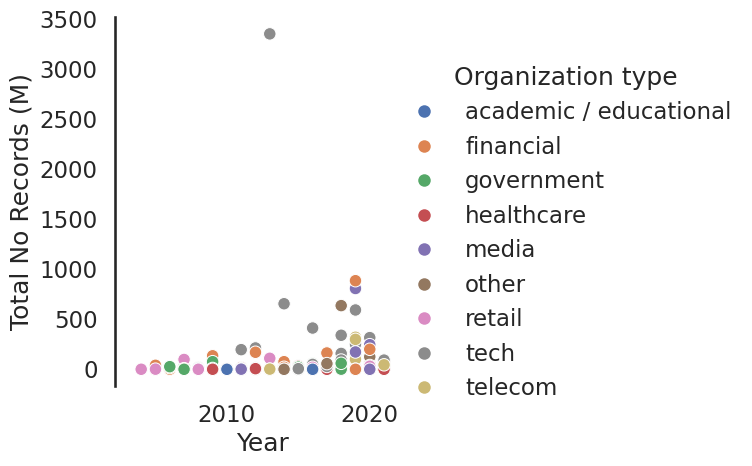

In [ ]:
sns.relplot(data=data_breaches,
	x=data_breaches["Year"],
	y=data_breaches["Total No Records (M)"],
	hue=data_breaches["Organization type"])
sns.despine(offset=10, bottom=True)

In [ ]:
sns.color_palette(palette="husl",
	  n_colors=5,
	  desat=0.2,
	  as_cmap=False #if True, it returns the matplotlib.colors.Colormap object.
	  )

[(0.7571883596118243, 0.6518837597717406, 0.6707909108545999),
 (0.48587315611338217, 0.47281932385106673, 0.3886002777804059),
 (0.3970687359423678, 0.49497651780754615, 0.45275162387851625),
 (0.4411634660223879, 0.529706710342828, 0.5518454159921654),
 (0.7340940657037288, 0.669402069042724, 0.7655862858954001)]

In [ ]:
sns.color_palette()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [ ]:
sns.color_palette("pastel")#"tab10","muted","bright","colorblind", "deep","dark"- categorical scales

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

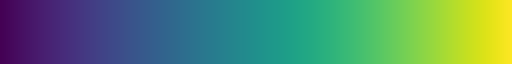

In [ ]:
sns.color_palette("viridis", as_cmap=True)#magma, rocket, mako, flare, crest - sequential sclaes

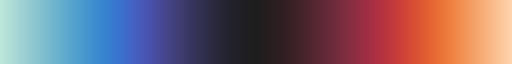

In [ ]:
sns.color_palette("icefire", as_cmap=True)#vlag, spectral, coolwarm - diverging sclaes

In [ ]:
fig = px.pie(
  data_frame=data_breaches,
  values="Count of Breaches",
  names="Method"
)
fig.update_traces(
  textposition='inside',
  textinfo='percent+label',
  marker_line_width=1
)
fig.show()

In [ ]:
fig = px.bar(data_frame=data_breaches,
  y="Count of Breaches",
  x="Organization type",
  color="Method",
  barmode="group",
  color_discrete_sequence=px.colors.qualitative.Antique
)
fig.update_layout(legend_bgcolor="#F7F0F5",
  plot_bgcolor="#F7F0F5",
  legend_orientation="h",
  legend_x=0.05,
  legend_y=-0.25
)
fig.show()


In [ ]:
import plotly.express as px

# Call px.colors.qualitative.swatches() to see available palettes
px.colors.qualitative.swatches()

# Create the bar plot
fig = px.bar(
    data_frame=data_breaches,
    x="Method",
    y="Count of Breaches",
    color="Organization type",
    barmode="group", # Changed barmode to 'group' as requested
    color_discrete_sequence=px.colors.qualitative.T10 # Using T10 palette, you can change this
)

fig.update_layout(
    legend_bgcolor="#F7F0F5",
    plot_bgcolor="#F7F0F5",
    legend_orientation="h",
    legend_x=0.05,
    legend_y=-0.25
)

fig.show()

In [ ]:
px.colors.qualitative.swatches()

# Create the bar plot
fig = px.bar(
    data_frame=data_breaches,
    x="Method",
    y="Total No Records (M)",
    color="Organization type",
    barmode="group",
    color_discrete_sequence=px.colors.qualitative.T10
)

fig.update_layout(
    legend_bgcolor="#F7F0F5",
    plot_bgcolor="#F7F0F5",
    legend_orientation="h",
    legend_x=0.05,
    legend_y=-0.25
)

fig.show()

create a pie chart illustrating the number of leaked records divided by sector that the affected organization is assigned to.


In [ ]:
fig = px.pie(
    data_frame=data_breaches,
    values="Total No Records (M)",
    names="Organization type"
)
fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    marker_line_width=1
)
fig.show()